# Asistente Inteligente para Seguridad Urbana en Costa Rica
### Módulos del Asistente Inteligente — RNN Predicción de incidencias
### Módulo 2: Predicción temporal de zonas y horarios de riesgo
### Integrantes :
### Profesor:

## 1. Importación de librerías


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#  2. Cargar datos


In [18]:
df = pd.read_csv("C:\\SmartCityIA\\data\\raw\\Estadisticas OIJ.csv")

df.head()

,Delito,SubDelito,Fecha,Rango Horario,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton
0,ASALTO,ARMA BLANCA,01/02/2022,12:00:00 - 14:59:59,VEHICULO,MOTOCICLETA/REPARTIDOR [VEHICULO],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,ASERRI
1,ASALTO,ARMA BLANCA,03/02/2022,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,ALAJUELA,ALAJUELA
2,ASALTO,ARMA BLANCA,04/02/2022,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,06/02/2022,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,08/02/2022,00:00:00 - 02:59:59,PERSONA,TURISTA/EXTRANJERO [PERSONA],Mayor de edad,HOMBRE,RUSIA,PUNTARENAS,GARABITO


# 3. Conversion de fecha

In [19]:
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)

df = df.sort_values('Fecha')

# Serie Temporal

In [20]:
serie = df.groupby("Fecha").size()

serie = serie.to_frame(name="Delitos")

serie.head()

serie.head()

,Delitos
Fecha,
2022-02-01,95
2022-02-02,110
2022-02-03,112
2022-02-04,143
2022-02-05,145


# Vizualizacion de la serie tempral

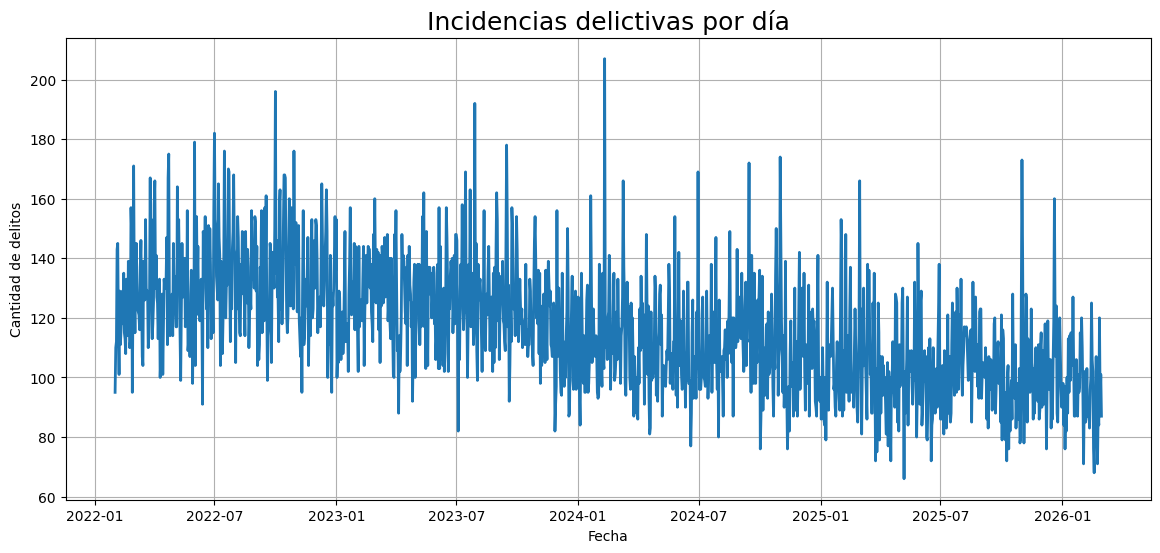

In [21]:
plt.figure(figsize=(14,6))

plt.plot(serie.index, serie["Delitos"], linewidth=2)

plt.title("Incidencias delictivas por día", fontsize=18)
plt.xlabel("Fecha")
plt.ylabel("Cantidad de delitos")

plt.grid(True)

plt.show()

# Normalizacion

In [22]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(serie)

# Secuencias RNN

In [23]:
window = 30

X = []
y = []

for i in range(window, len(data_scaled)):

    X.append(data_scaled[i-window:i])
    y.append(data_scaled[i])

X = np.array(X)
y = np.array(y)

print(X.shape)

(1460, 30, 1)


# Train / Test

In [24]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Modelo LSTM

In [25]:
model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1],1)))

model.add(LSTM(50))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

C:\SmartCityIA\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

# Entranamiento de Modelo

In [26]:
history = model.fit(

    X_train,
    y_train,

    epochs=20,
    batch_size=32,

    validation_data=(X_test,y_test)
)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0294 - val_loss: 0.0109
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0175 - val_loss: 0.0115
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0167 - val_loss: 0.0114
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0167 - val_loss: 0.0121
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0163 - val_loss: 0.0136
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0172 - val_loss: 0.0119
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0170 - val_loss: 0.0122
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0159 - val_loss: 0.0113
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0159 - val_loss: 0.0112
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0162 - val_loss: 0.0125
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0169 - val_loss: 0.0112
Epoch 12/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

# Prediccion

In [27]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_real = scaler.inverse_transform(y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


# Grafico de Perdida

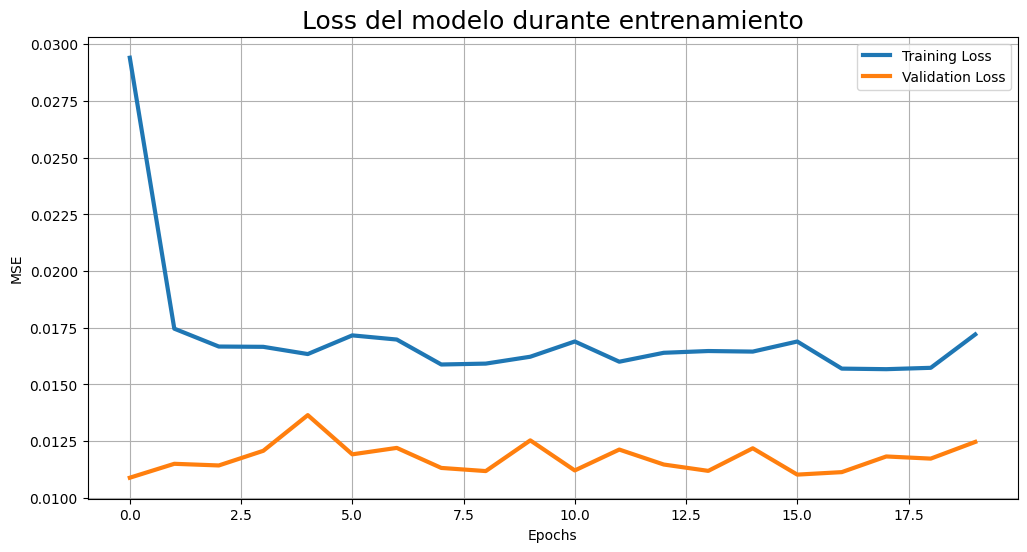

In [28]:
plt.figure(figsize=(12,6))

plt.plot(history.history["loss"], linewidth=3)
plt.plot(history.history["val_loss"], linewidth=3)

plt.title("Loss del modelo durante entrenamiento", fontsize=18)

plt.xlabel("Epochs")
plt.ylabel("MSE")

plt.legend(["Training Loss","Validation Loss"])

plt.grid(True)

plt.show()

# Comparacion

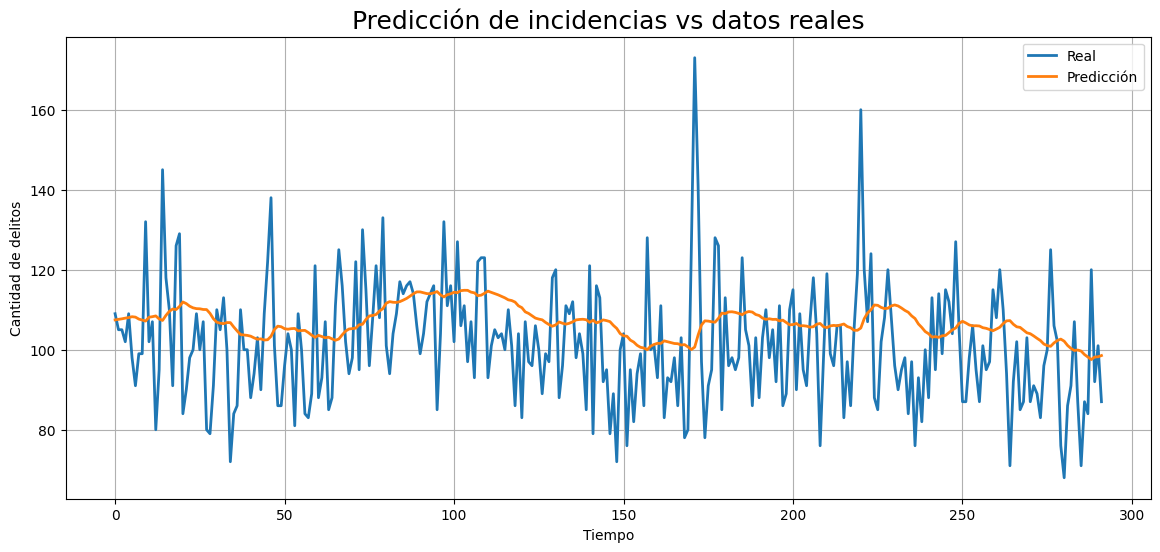

In [29]:
plt.figure(figsize=(14,6))

plt.plot(y_real, linewidth=2)
plt.plot(pred, linewidth=2)

plt.title("Predicción de incidencias vs datos reales", fontsize=18)

plt.xlabel("Tiempo")
plt.ylabel("Cantidad de delitos")

plt.legend(["Real","Predicción"])

plt.grid(True)

plt.show()

# Metricas

In [30]:
mae = mean_absolute_error(y_real, pred)

rmse = np.sqrt(mean_squared_error(y_real, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 12.484608219094472
RMSE: 15.742740301956694


# Prediccion futura

In [31]:
last_window = data_scaled[-30:]

future_predictions = []

current_window = last_window.copy()

for i in range(4):

    pred = model.predict(current_window.reshape(1,30,1))

    future_predictions.append(pred[0,0])

    current_window = np.append(current_window[1:], pred)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

print("Predicción futura:", future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicción futura: [[98.38719 ]
 [98.5431  ]
 [98.84952 ]
 [99.302475]]


# Reporte de Clasificación y Matriz de Confusión

Como este es un modelo de **regresión** de series temporales, adaptamos las métricas de clasificación usando **umbrales de nivel de incidencias**:
- **Bajo**: menos de 120 delitos por día
- **Medio**: entre 120 y 160 delitos por día  
- **Alto**: más de 160 delitos por día

In [32]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


def categorizar_incidencias(valores, umbral_bajo=120, umbral_alto=160):
    """
    Categoriza valores en niveles:
    0 = Bajo  (< umbral_bajo)
    1 = Medio (umbral_bajo <= x <= umbral_alto)
    2 = Alto  (> umbral_alto)
    """
    categorias = []
    for v in valores.flatten():
        if v < umbral_bajo:
            categorias.append(0)   # Bajo
        elif v <= umbral_alto:
            categorias.append(1)   # Medio
        else:
            categorias.append(2)   # Alto
    return np.array(categorias)


pred_test = model.predict(X_test)
pred_test_real = scaler.inverse_transform(pred_test)
y_test_real   = scaler.inverse_transform(y_test)


y_real_cat = categorizar_incidencias(y_test_real)
y_pred_cat = categorizar_incidencias(pred_test_real)

nombres_clases = ['Bajo (<120)', 'Medio (120-160)', 'Alto (>160)']

# --- Classification Report ---
print('=' * 60)
print('REPORTE DE CLASIFICACIÓN POR NIVEL DE INCIDENCIAS')
print('=' * 60)
print(classification_report(
    y_real_cat,
    y_pred_cat,
    target_names=nombres_clases,
    zero_division=0
))


accuracy = np.mean(y_real_cat == y_pred_cat)
print(f'Accuracy por nivel: {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Total muestras en test: {len(y_real_cat)}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
REPORTE DE CLASIFICACIÓN POR NIVEL DE INCIDENCIAS
                 precision    recall  f1-score   support

    Bajo (<120)       0.88      1.00      0.94       258
Medio (120-160)       0.00      0.00      0.00        33
    Alto (>160)       0.00      0.00      0.00         1

       accuracy                           0.88       292
      macro avg       0.29      0.33      0.31       292
   weighted avg       0.78      0.88      0.83       292

Accuracy por nivel: 0.8836 (88.36%)
Total muestras en test: 292


# Matriz de Confusión

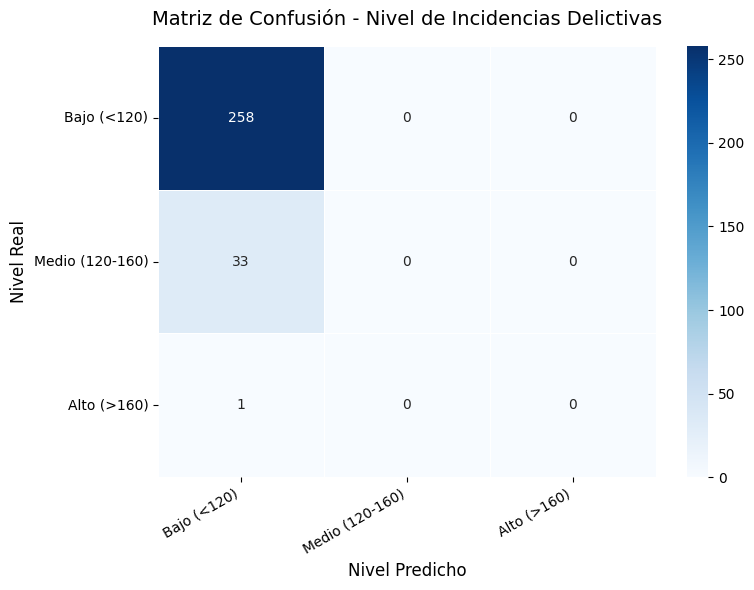


Interpretación de la Matriz de Confusión:
  - Diagonal principal: predicciones correctas por nivel
  - Fuera de diagonal:  errores de clasificación

  Bajo   predicho correctamente: 258 de 258
  Medio  predicho correctamente: 0 de 33
  Alto   predicho correctamente: 0 de 1


In [33]:
# --- Matriz de Confusión ---
cm = confusion_matrix(y_real_cat, y_pred_cat)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nombres_clases,
    yticklabels=nombres_clases,
    linewidths=0.5
)

plt.title('Matriz de Confusión - Nivel de Incidencias Delictivas', fontsize=14, pad=15)
plt.xlabel('Nivel Predicho', fontsize=12)
plt.ylabel('Nivel Real', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nInterpretación de la Matriz de Confusión:')
print('  - Diagonal principal: predicciones correctas por nivel')
print('  - Fuera de diagonal:  errores de clasificación')
print(f'\n  Bajo   predicho correctamente: {cm[0,0]} de {cm[0].sum()}')
print(f'  Medio  predicho correctamente: {cm[1,1]} de {cm[1].sum()}')
print(f'  Alto   predicho correctamente: {cm[2,2]} de {cm[2].sum()}')

# Resumen de Métricas del Modelo

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test_real, pred_test_real)
rmse = np.sqrt(mean_squared_error(y_test_real, pred_test_real))
r2   = r2_score(y_test_real, pred_test_real)

print('=' * 60)
print('MÉTRICAS DE REGRESIÓN (Conjunto de Prueba)')
print('=' * 60)
print(f'MAE  (Error Absoluto Medio):         {mae:.4f} delitos/día')
print(f'RMSE (Raíz del Error Cuadrático):    {rmse:.4f} delitos/día')
print(f'R²   (Coeficiente de Determinación): {r2:.4f}')
print()
print('=' * 60)
print('MÉTRICAS DE CLASIFICACIÓN POR NIVEL')
print('=' * 60)
print(f'Accuracy: {accuracy*100:.2f}%')
print()
print('Nota: La clasificación por nivel evalúa si el modelo')
print('predice correctamente la CATEGORÍA de incidencias')
print('(Bajo / Medio / Alto), no el valor exacto.')

MÉTRICAS DE REGRESIÓN (Conjunto de Prueba)
MAE  (Error Absoluto Medio):         12.4846 delitos/día
RMSE (Raíz del Error Cuadrático):    15.7427 delitos/día
R²   (Coeficiente de Determinación): -0.1341

MÉTRICAS DE CLASIFICACIÓN POR NIVEL
Accuracy: 88.36%

Nota: La clasificación por nivel evalúa si el modelo
predice correctamente la CATEGORÍA de incidencias
(Bajo / Medio / Alto), no el valor exacto.
